In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("EDA environment setup completed successfully!")



EDA environment setup completed successfully!


In [4]:
# --------------------------------------------------
# Load Cleaned Dataset
# --------------------------------------------------

DATA_PATH = "../data/cleaned_student_placement_data.csv"

df = pd.read_csv(
    DATA_PATH,
    keep_default_na=False
)

print("Cleaned dataset loaded successfully!")

print(f"\nNumber of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

df.head()

Cleaned dataset loaded successfully!

Number of Rows: 5000
Number of Columns: 31


,Student_ID,Age,Gender,Branch,Graduation_Year,CGPA,LeetCode_Problems,DSA_Level,GitHub_Repositories,Open_Source_Contribution,Total_Projects,Major_Project_Level,AI_ML_Projects,Deployment_Experience,Internship_Count,Internship_Domain,Python_Level,SQL_Level,PowerBI_Level,MachineLearning_Level,Statistics_Level,DeepLearning_Level,LinkedIn_Profile,GitHub_Profile,Portfolio_Website,Industry_Certifications,Communication_Level,Target_Role,Preferred_Domain,Placement_Score,Placement_Status
0,1001,23,Male,CSE,2027,5.89,218,Intermediate,6,Yes,4,Intermediate,3,Yes,0,None,Intermediate,Intermediate,Intermediate,Advanced,Intermediate,Beginner,Yes,Yes,No,1,Excellent,Data Analyst,Data Analytics,48.55,Placed
1,1002,24,Male,CSE,2025,6.58,81,Beginner,2,No,4,Intermediate,2,Yes,1,Data Analytics,Beginner,Intermediate,Advanced,Beginner,Intermediate,Beginner,Yes,Yes,No,1,Average,Data Scientist,Data Science,38.67,Not Placed
2,1003,22,Female,AI/ML,2028,7.35,22,Beginner,1,No,1,Basic,1,No,0,None,Beginner,Intermediate,None,None,Beginner,Beginner,Yes,Yes,No,5,Good,Data Engineer,Data Engineering,28.43,Not Placed
3,1004,24,Male,AI/ML,2026,6.61,55,Beginner,6,Yes,4,Intermediate,3,No,1,Cybersecurity,Advanced,Intermediate,Intermediate,Beginner,Beginner,Beginner,Yes,Yes,No,4,Good,AI Engineer,AI/ML,42.54,Placed
4,1005,24,Male,CSE,2027,6.68,249,Intermediate,6,No,2,Intermediate,2,Yes,1,Data Analytics,Intermediate,Advanced,None,Beginner,Advanced,Intermediate,No,Yes,No,1,Good,Data Analyst,Data Analytics,46.70,Placed


# Career Compass — Exploratory Data Analysis

## Project Overview

Career Compass is an AI-powered Student Placement Intelligence and Career Readiness Platform designed to analyze student profiles, predict placement outcomes, identify skill gaps, and provide personalized career recommendations.

## EDA Objectives

The objectives of this exploratory data analysis are to:

- Understand the structure and characteristics of the student placement dataset.
- Analyze the distribution of numerical and categorical features.
- Identify patterns associated with student placement outcomes.
- Explore relationships between academic performance, coding experience, projects, internships, technical skills, and placement success.
- Identify potentially redundant or highly related features before machine learning.
- Generate insights that can support feature engineering and model development.

> **Important Modeling Note:** `Placement_Score` was used only as part of the synthetic target-generation process. It will not be used as an input feature during machine learning model training to prevent target leakage.

In [148]:
# --------------------------------------------------
# Dataset Overview
# --------------------------------------------------

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")

print("\nColumn Names:")

for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:", df.isnull().sum().sum())

print("Duplicate Records:", df.duplicated().sum())

DATASET OVERVIEW

Dataset Shape: (5000, 31)

Column Names:
1. Student_ID
2. Age
3. Gender
4. Branch
5. Graduation_Year
6. CGPA
7. LeetCode_Problems
8. DSA_Level
9. GitHub_Repositories
10. Open_Source_Contribution
11. Total_Projects
12. Major_Project_Level
13. AI_ML_Projects
14. Deployment_Experience
15. Internship_Count
16. Internship_Domain
17. Python_Level
18. SQL_Level
19. PowerBI_Level
20. MachineLearning_Level
21. Statistics_Level
22. DeepLearning_Level
23. LinkedIn_Profile
24. GitHub_Profile
25. Portfolio_Website
26. Industry_Certifications
27. Communication_Level
28. Target_Role
29. Preferred_Domain
30. Placement_Score
31. Placement_Status

Data Types:
Student_ID                    int64
Age                           int64
Gender                       object
Branch                       object
Graduation_Year               int64
CGPA                        float64
LeetCode_Problems             int64
DSA_Level                    object
GitHub_Repositories           int64
Open_Sou

## 1. Target Variable Analysis

The target variable `Placement_Status` represents whether a student was placed or not placed.

Analyzing the target distribution helps determine whether the dataset is balanced and whether class imbalance may need to be addressed during machine learning model development.

In [149]:
# --------------------------------------------------
# Placement Status Distribution
# --------------------------------------------------

placement_counts = df["Placement_Status"].value_counts()

placement_percentages = (
    df["Placement_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Placement Status Counts:")
print(placement_counts)

print("\nPlacement Status Percentages:")
print(placement_percentages)

Placement Status Counts:
Placement_Status
Not Placed    2731
Placed        2269
Name: count, dtype: int64

Placement Status Percentages:
Placement_Status
Not Placed    54.62
Placed        45.38
Name: proportion, dtype: float64


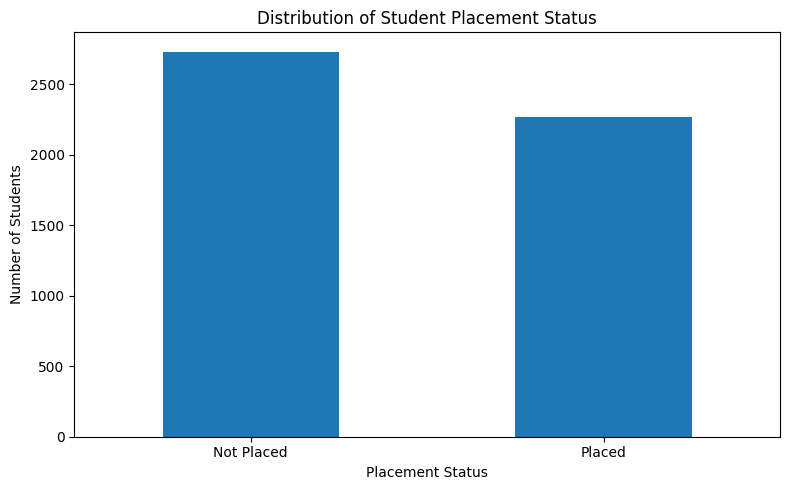

In [150]:
# --------------------------------------------------
# Visualize Placement Status Distribution
# --------------------------------------------------

placement_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Student Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 2. Numerical Feature Analysis

### 2.1 CGPA Distribution

This analysis examines the overall distribution of students' CGPA values and helps identify the central tendency, spread, and shape of academic performance in the dataset.

In [151]:
# --------------------------------------------------
# CGPA Descriptive Statistics
# --------------------------------------------------

print("CGPA Descriptive Statistics:")

print(df["CGPA"].describe())

CGPA Descriptive Statistics:
count    5000.000000
mean        7.529744
std         0.997570
min         5.000000
25%         6.840000
50%         7.530000
75%         8.220000
max        10.000000
Name: CGPA, dtype: float64


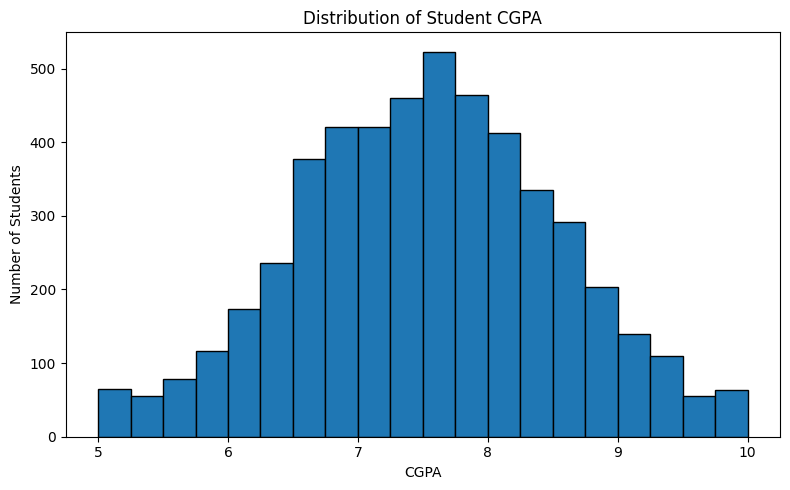

In [152]:
# --------------------------------------------------
# Visualize CGPA Distribution
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["CGPA"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Student CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### 2.2 LeetCode Problems Distribution

This analysis examines the distribution of LeetCode problems solved by students. It helps understand students' coding practice levels and identify the spread and concentration of problem-solving experience in the dataset.

In [153]:
# --------------------------------------------------
# LeetCode Problems Descriptive Statistics
# --------------------------------------------------

print("LeetCode Problems Descriptive Statistics:")

print(df["LeetCode_Problems"].describe())

LeetCode Problems Descriptive Statistics:
count    5000.000000
mean      159.821000
std       113.098127
min         0.000000
25%        76.000000
50%       134.000000
75%       215.000000
max      1000.000000
Name: LeetCode_Problems, dtype: float64


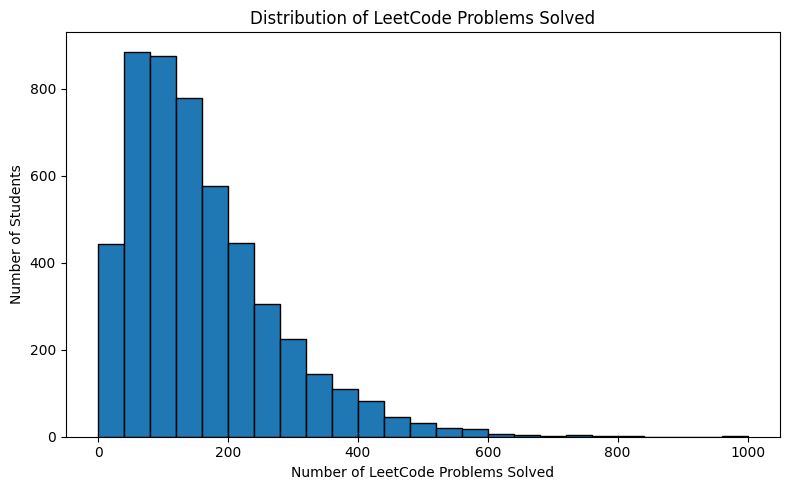

In [154]:
# --------------------------------------------------
# Visualize LeetCode Problems Distribution
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df["LeetCode_Problems"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of LeetCode Problems Solved")
plt.xlabel("Number of LeetCode Problems Solved")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### 2.3 Project and Internship Experience Distribution

This analysis examines students' practical experience through total projects, AI/ML-specific projects, and internships. These features provide insights into students' exposure to hands-on development and industry experience.

In [155]:
# --------------------------------------------------
# Project and Internship Descriptive Statistics
# --------------------------------------------------

experience_features = [
    "Total_Projects",
    "AI_ML_Projects",
    "Internship_Count"
]

print("Project and Internship Descriptive Statistics:")

print(df[experience_features].describe())

Project and Internship Descriptive Statistics:
       Total_Projects  AI_ML_Projects  Internship_Count
count     5000.000000     5000.000000       5000.000000
mean         2.978000        1.461000          0.954600
std          1.707776        1.461132          0.859236
min          0.000000        0.000000          0.000000
25%          2.000000        0.000000          0.000000
50%          3.000000        1.000000          1.000000
75%          4.000000        2.000000          2.000000
max         10.000000        8.000000          3.000000


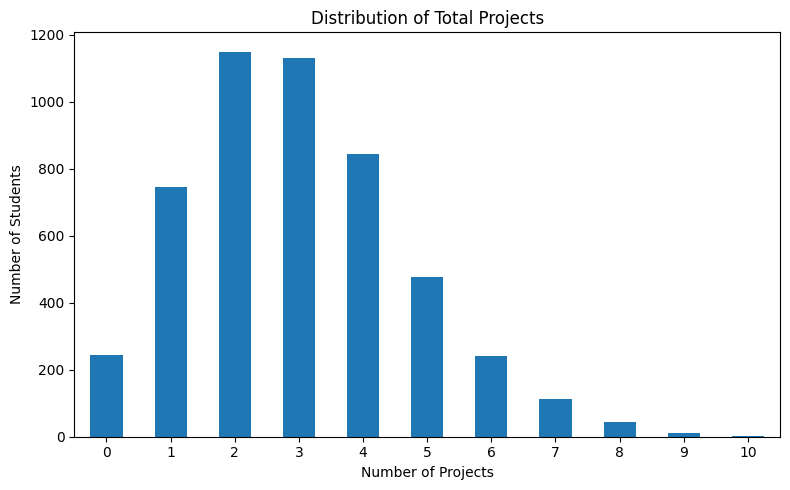

In [156]:
# --------------------------------------------------
# Total Projects Distribution
# --------------------------------------------------

total_projects_counts = (
    df["Total_Projects"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

total_projects_counts.plot(kind="bar")

plt.title("Distribution of Total Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

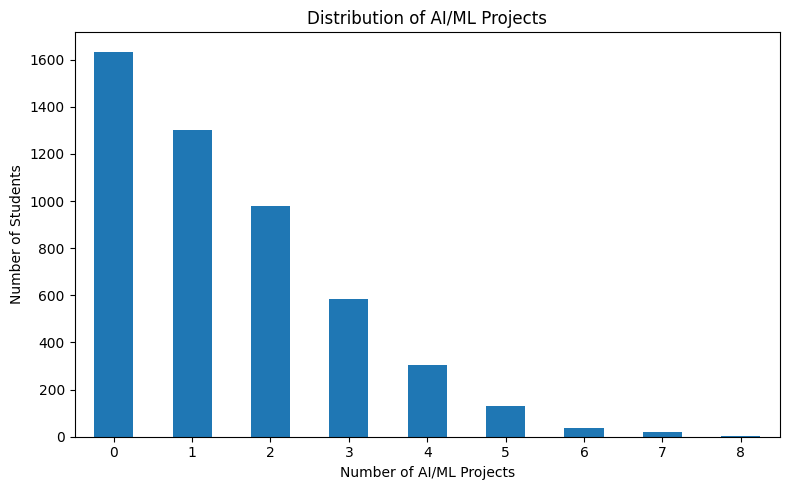

In [157]:
# --------------------------------------------------
# AI/ML Projects Distribution
# --------------------------------------------------

ai_ml_projects_counts = (
    df["AI_ML_Projects"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

ai_ml_projects_counts.plot(kind="bar")

plt.title("Distribution of AI/ML Projects")
plt.xlabel("Number of AI/ML Projects")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

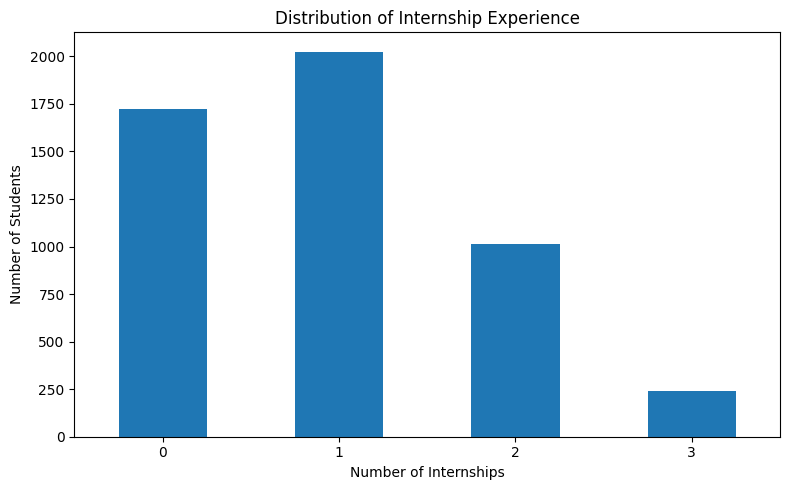

In [158]:
# --------------------------------------------------
# Internship Count Distribution
# --------------------------------------------------

internship_counts = (
    df["Internship_Count"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

internship_counts.plot(kind="bar")

plt.title("Distribution of Internship Experience")
plt.xlabel("Number of Internships")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3. Categorical Feature Analysis

### 3.1 DSA Level Distribution

This analysis examines the distribution of students across different DSA proficiency levels. Understanding this distribution helps evaluate the overall problem-solving and algorithmic skill levels represented in the dataset.

In [159]:
# --------------------------------------------------
# DSA Level Distribution
# --------------------------------------------------

dsa_order = [
    "Beginner",
    "Intermediate",
    "Advanced"
]

dsa_counts = (
    df["DSA_Level"]
    .value_counts()
    .reindex(dsa_order)
)

print("DSA Level Counts:")

print(dsa_counts)


print("\nDSA Level Percentages:")

print(
    df["DSA_Level"]
    .value_counts(normalize=True)
    .reindex(dsa_order)
    .mul(100)
    .round(2)
)

DSA Level Counts:
DSA_Level
Beginner        1772
Intermediate    2663
Advanced         565
Name: count, dtype: int64

DSA Level Percentages:
DSA_Level
Beginner        35.44
Intermediate    53.26
Advanced        11.30
Name: proportion, dtype: float64


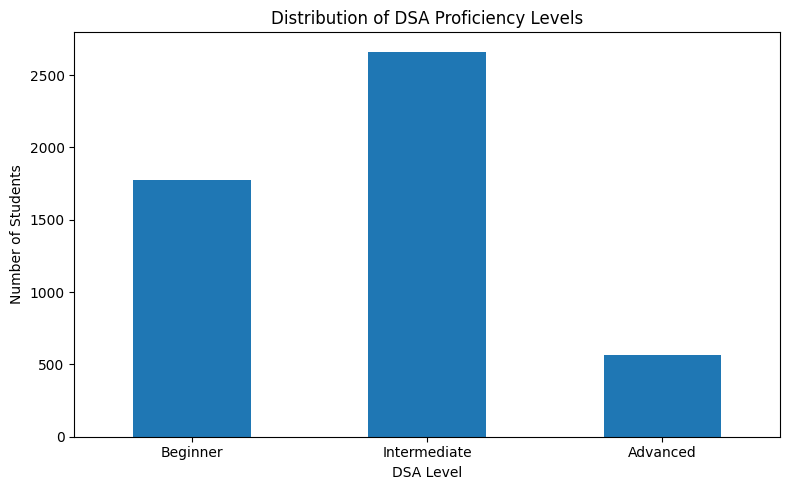

In [160]:
# --------------------------------------------------
# Visualize DSA Level Distribution
# --------------------------------------------------

plt.figure(figsize=(8, 5))

dsa_counts.plot(kind="bar")

plt.title("Distribution of DSA Proficiency Levels")
plt.xlabel("DSA Level")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 3.2 Technical Skill Level Distribution

This analysis examines proficiency levels across key technical skills. It helps identify the overall skill composition of students and provides a foundation for later role-based skill-gap analysis and personalized recommendations.

In [161]:
# --------------------------------------------------
# Technical Skill Distribution
# --------------------------------------------------

technical_skills = [
    "Python_Level",
    "SQL_Level",
    "PowerBI_Level",
    "MachineLearning_Level",
    "Statistics_Level",
    "DeepLearning_Level"
]

skill_order = [
    "None",
    "Beginner",
    "Intermediate",
    "Advanced"
]


for skill in technical_skills:

    print("\n" + "=" * 50)

    print(f"{skill} Distribution")

    skill_counts = (
        df[skill]
        .value_counts()
        .reindex(skill_order, fill_value=0)
    )

    print(skill_counts)


Python_Level Distribution
Python_Level
None             255
Beginner        1253
Intermediate    2496
Advanced         996
Name: count, dtype: int64

SQL_Level Distribution
SQL_Level
None             761
Beginner        1707
Intermediate    2041
Advanced         491
Name: count, dtype: int64

PowerBI_Level Distribution
PowerBI_Level
None            1811
Beginner        1415
Intermediate    1266
Advanced         508
Name: count, dtype: int64

MachineLearning_Level Distribution
MachineLearning_Level
None             981
Beginner        1785
Intermediate    1748
Advanced         486
Name: count, dtype: int64

Statistics_Level Distribution
Statistics_Level
None             527
Beginner        1723
Intermediate    2246
Advanced         504
Name: count, dtype: int64

DeepLearning_Level Distribution
DeepLearning_Level
None             493
Beginner        1528
Intermediate    2229
Advanced         750
Name: count, dtype: int64


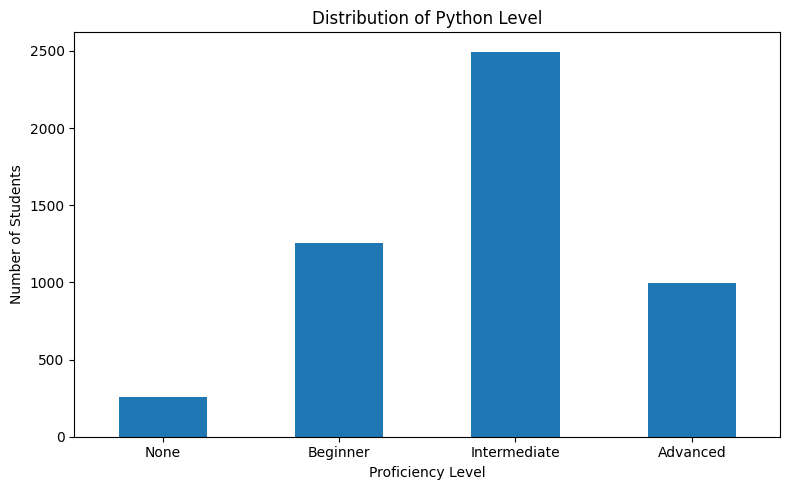

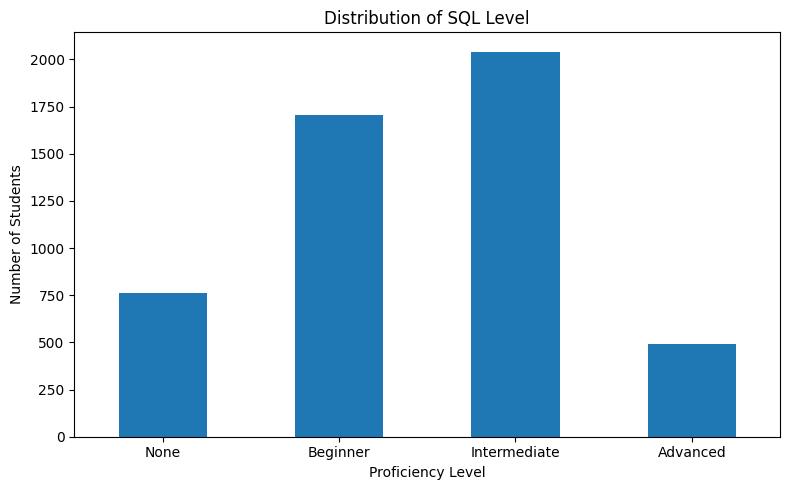

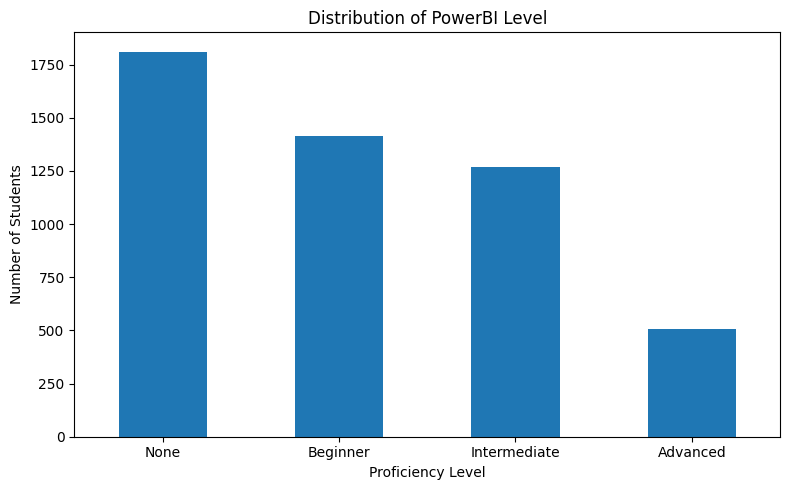

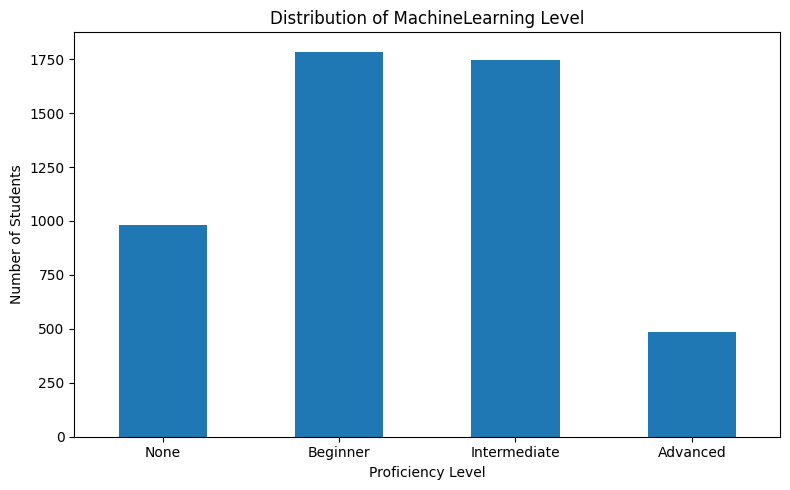

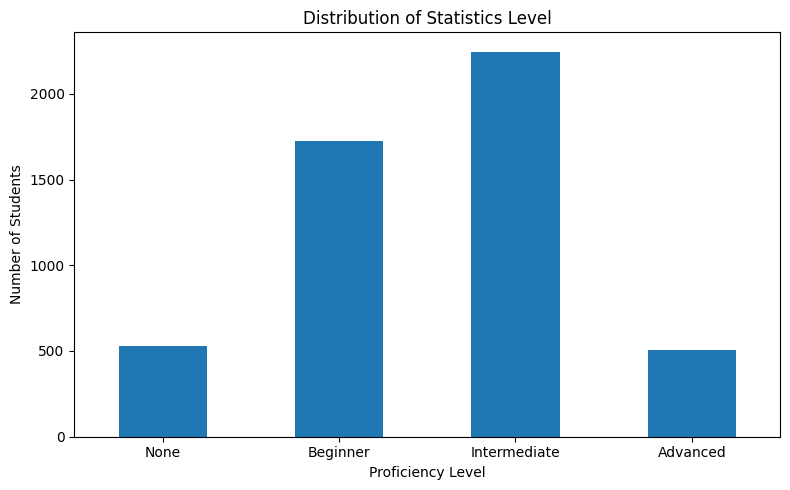

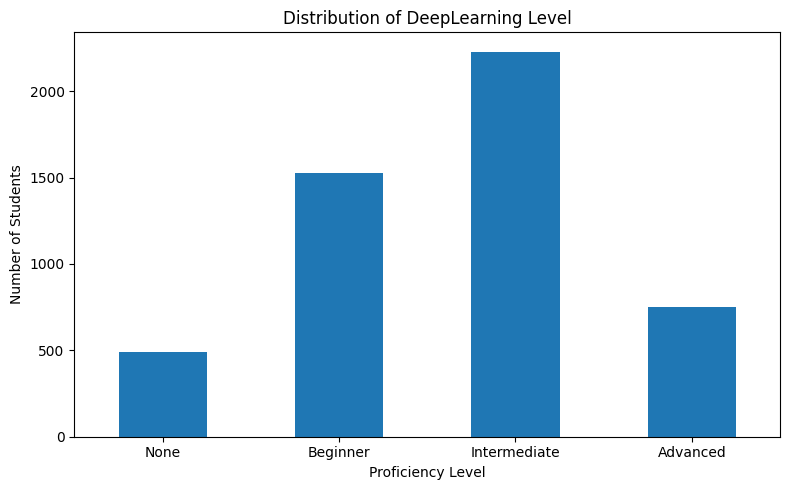

In [162]:
# --------------------------------------------------
# Visualize Technical Skill Distributions
# --------------------------------------------------

for skill in technical_skills:

    skill_counts = (
        df[skill]
        .value_counts()
        .reindex(skill_order, fill_value=0)
    )

    plt.figure(figsize=(8, 5))

    skill_counts.plot(kind="bar")

    plt.title(
        f"Distribution of {skill.replace('_', ' ')}"
    )

    plt.xlabel("Proficiency Level")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

## 4. Bivariate Analysis: Factors Associated with Placement

### 4.1 CGPA vs Placement Status

This analysis compares the academic performance of placed and non-placed students to examine whether CGPA is associated with placement outcomes.

In [163]:
# --------------------------------------------------
# CGPA Statistics by Placement Status
# --------------------------------------------------

cgpa_by_placement = (
    df.groupby("Placement_Status")["CGPA"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(2)
)

print("CGPA Statistics by Placement Status:")

cgpa_by_placement

CGPA Statistics by Placement Status:


,count,mean,median,min,max,std
Placement_Status,,,,,,
Not Placed,2731,7.39,7.37,5.0,10.0,0.98
Placed,2269,7.70,7.70,5.0,10.0,1.00


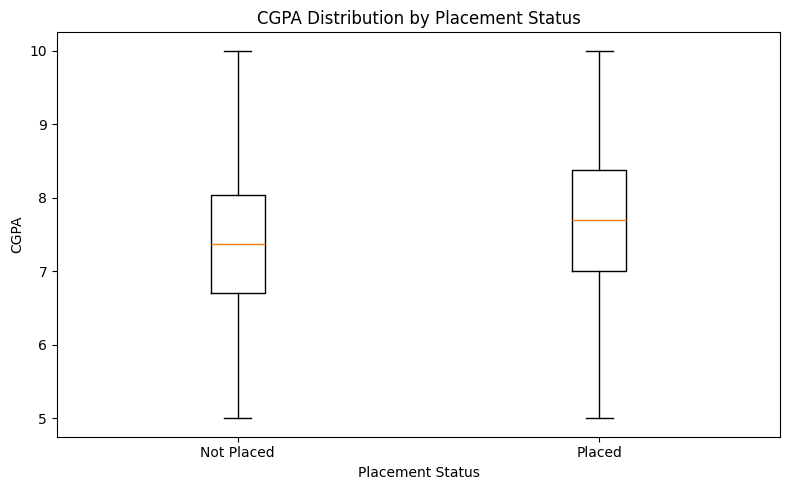

In [164]:
# --------------------------------------------------
# Visualize CGPA vs Placement Status
# --------------------------------------------------

placement_order = [
    "Not Placed",
    "Placed"
]

cgpa_data = [
    df.loc[
        df["Placement_Status"] == status,
        "CGPA"
    ]
    for status in placement_order
]


plt.figure(figsize=(8, 5))

plt.boxplot(
    cgpa_data,
    tick_labels=placement_order
)

plt.title("CGPA Distribution by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")

plt.tight_layout()
plt.show()

### 4.2 LeetCode Problems Solved vs Placement Status

This analysis compares coding practice levels between placed and non-placed students by examining the number of LeetCode problems solved.

In [165]:
# --------------------------------------------------
# LeetCode Statistics by Placement Status
# --------------------------------------------------

leetcode_by_placement = (
    df.groupby("Placement_Status")["LeetCode_Problems"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(2)
)

print("LeetCode Statistics by Placement Status:")

leetcode_by_placement

LeetCode Statistics by Placement Status:


,count,mean,median,min,max,std
Placement_Status,,,,,,
Not Placed,2731,137.76,116.0,0,757,98.20
Placed,2269,186.38,158.0,3,1000,123.67


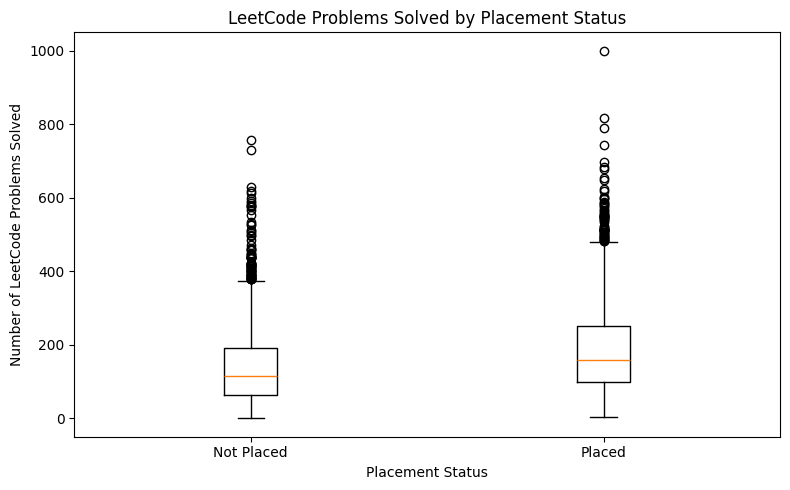

In [166]:
# --------------------------------------------------
# Visualize LeetCode Problems vs Placement Status
# --------------------------------------------------

leetcode_data = [
    df.loc[
        df["Placement_Status"] == status,
        "LeetCode_Problems"
    ]
    for status in placement_order
]


plt.figure(figsize=(8, 5))

plt.boxplot(
    leetcode_data,
    tick_labels=placement_order
)

plt.title("LeetCode Problems Solved by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of LeetCode Problems Solved")

plt.tight_layout()
plt.show()

### 4.3 Project Experience vs Placement Status

This analysis compares the project experience of placed and non-placed students. It examines both total project involvement and AI/ML-specific project experience to understand their association with placement outcomes.

In [167]:
# --------------------------------------------------
# Project Statistics by Placement Status
# --------------------------------------------------

project_features = [
    "Total_Projects",
    "AI_ML_Projects"
]

project_statistics = (
    df.groupby("Placement_Status")[project_features]
    .agg(["mean", "median", "std"])
    .round(2)
)

print("Project Statistics by Placement Status:")

project_statistics

Project Statistics by Placement Status:


Total_Projects              AI_ML_Projects             
                           mean median   std           mean median   std
Placement_Status                                                        
Not Placed                 2.70    3.0  1.62           1.31    1.0  1.38
Placed                     3.32    3.0  1.75           1.65    1.0  1.54

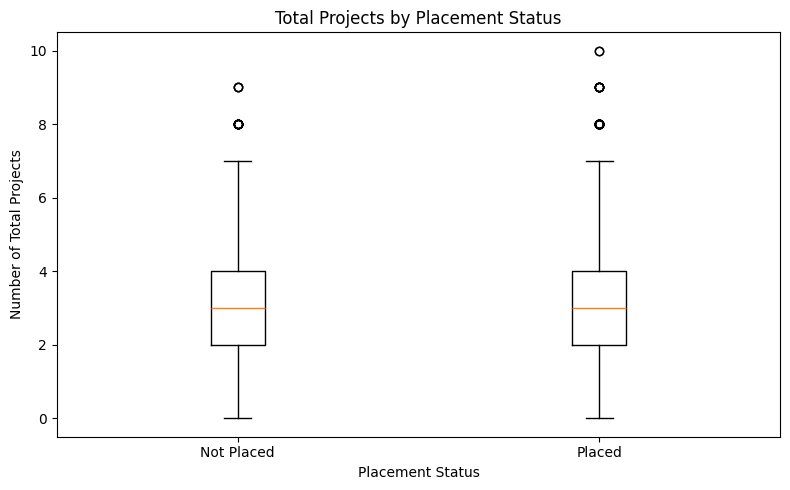

In [168]:
# --------------------------------------------------
# Total Projects vs Placement Status
# --------------------------------------------------

total_projects_data = [
    df.loc[
        df["Placement_Status"] == status,
        "Total_Projects"
    ]
    for status in placement_order
]


plt.figure(figsize=(8, 5))

plt.boxplot(
    total_projects_data,
    tick_labels=placement_order
)

plt.title("Total Projects by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Total Projects")

plt.tight_layout()
plt.show()

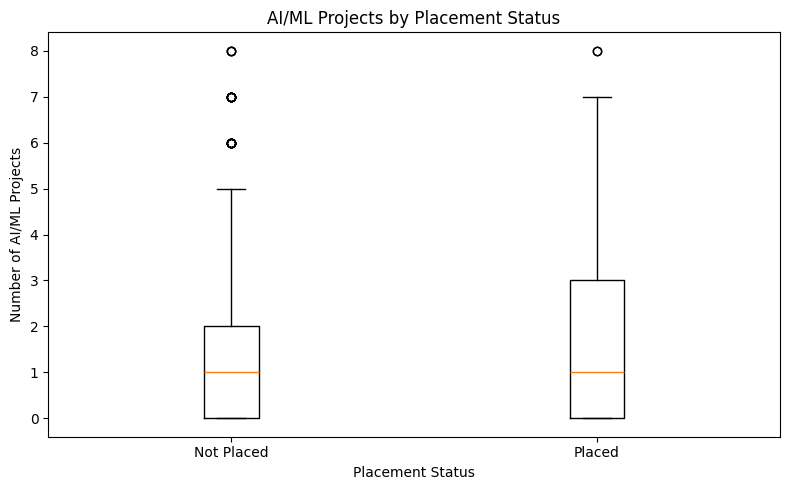

In [169]:
# --------------------------------------------------
# AI/ML Projects vs Placement Status
# --------------------------------------------------

ai_ml_projects_data = [
    df.loc[
        df["Placement_Status"] == status,
        "AI_ML_Projects"
    ]
    for status in placement_order
]


plt.figure(figsize=(8, 5))

plt.boxplot(
    ai_ml_projects_data,
    tick_labels=placement_order
)

plt.title("AI/ML Projects by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of AI/ML Projects")

plt.tight_layout()
plt.show()

### 4.4 Internship Experience vs Placement Status

This analysis examines the relationship between the number of internships completed by students and their placement outcomes. Internship experience represents practical industry exposure and may be associated with improved placement readiness.

In [170]:
# --------------------------------------------------
# Internship Statistics by Placement Status
# --------------------------------------------------

internship_statistics = (
    df.groupby("Placement_Status")["Internship_Count"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("Internship Statistics by Placement Status:")

internship_statistics

Internship Statistics by Placement Status:


,count,mean,median,std
Placement_Status,,,,
Not Placed,2731,0.82,1.0,0.8
Placed,2269,1.11,1.0,0.9


In [171]:
# --------------------------------------------------
# Placement Rate by Internship Count
# --------------------------------------------------

internship_placement_rate = (
    df.groupby("Internship_Count")["Placement_Status"]
    .apply(
        lambda x: (x == "Placed").mean() * 100
    )
    .round(2)
)

print("Placement Rate by Internship Count:")

print(internship_placement_rate)

Placement Rate by Internship Count:
Internship_Count
0    36.64
1    45.14
2    55.39
3    67.77
Name: Placement_Status, dtype: float64


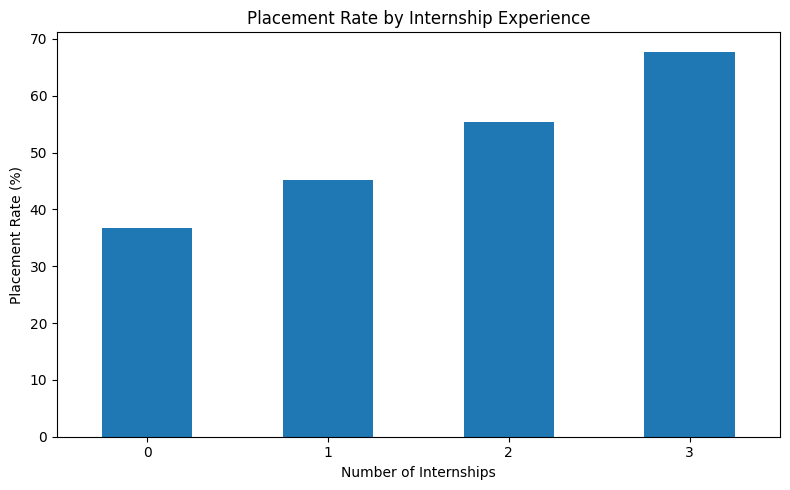

In [172]:
# --------------------------------------------------
# Visualize Placement Rate by Internship Count
# --------------------------------------------------

plt.figure(figsize=(8, 5))

internship_placement_rate.plot(kind="bar")

plt.title("Placement Rate by Internship Experience")
plt.xlabel("Number of Internships")
plt.ylabel("Placement Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 4.5 DSA Level vs Placement Status

This analysis examines placement outcomes across different DSA proficiency levels. It helps evaluate how problem-solving and algorithmic proficiency are associated with student placement outcomes.

In [173]:
# --------------------------------------------------
# Placement Counts by DSA Level
# --------------------------------------------------

dsa_placement_counts = pd.crosstab(
    df["DSA_Level"],
    df["Placement_Status"]
)

dsa_placement_counts = dsa_placement_counts.reindex(
    dsa_order
)

print("Placement Counts by DSA Level:")

dsa_placement_counts

Placement Counts by DSA Level:


Placement_Status,Not Placed,Placed
DSA_Level,,
Beginner,1201,571
Intermediate,1362,1301
Advanced,168,397


In [174]:
# --------------------------------------------------
# Placement Rate by DSA Level
# --------------------------------------------------

dsa_placement_rate = (
    df.groupby("DSA_Level")["Placement_Status"]
    .apply(
        lambda x: (x == "Placed").mean() * 100
    )
    .reindex(dsa_order)
    .round(2)
)

print("Placement Rate by DSA Level:")

print(dsa_placement_rate)

Placement Rate by DSA Level:
DSA_Level
Beginner        32.22
Intermediate    48.85
Advanced        70.27
Name: Placement_Status, dtype: float64


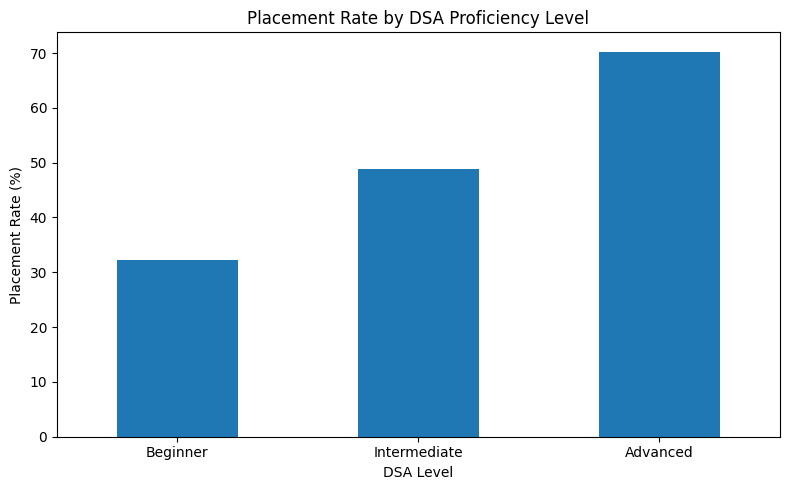

In [175]:
# --------------------------------------------------
# Visualize Placement Rate by DSA Level
# --------------------------------------------------

plt.figure(figsize=(8, 5))

dsa_placement_rate.plot(kind="bar")

plt.title("Placement Rate by DSA Proficiency Level")
plt.xlabel("DSA Level")
plt.ylabel("Placement Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 4.6 Communication Level vs Placement Status

This analysis examines placement rates across different communication proficiency levels. It helps evaluate the association between communication skills and student placement outcomes.

In [176]:
# --------------------------------------------------
# Placement Counts by Communication Level
# --------------------------------------------------

communication_order = [
    "Poor",
    "Average",
    "Good",
    "Excellent"
]

communication_placement_counts = pd.crosstab(
    df["Communication_Level"],
    df["Placement_Status"]
)

communication_placement_counts = (
    communication_placement_counts
    .reindex(communication_order)
)

print("Placement Counts by Communication Level:")

communication_placement_counts

Placement Counts by Communication Level:


Placement_Status,Not Placed,Placed
Communication_Level,,
Poor,286,185
Average,982,737
Good,1086,947
Excellent,377,400


In [177]:
# --------------------------------------------------
# Placement Rate by Communication Level
# --------------------------------------------------

communication_placement_rate = (
    df.groupby("Communication_Level")["Placement_Status"]
    .apply(
        lambda x: (x == "Placed").mean() * 100
    )
    .reindex(communication_order)
    .round(2)
)

print("Placement Rate by Communication Level:")

print(communication_placement_rate)

Placement Rate by Communication Level:
Communication_Level
Poor         39.28
Average      42.87
Good         46.58
Excellent    51.48
Name: Placement_Status, dtype: float64


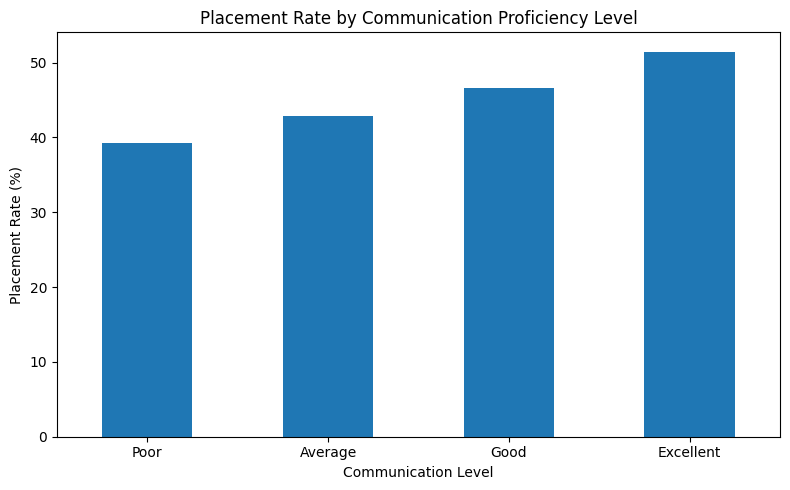

In [178]:
# --------------------------------------------------
# Visualize Placement Rate by Communication Level
# --------------------------------------------------

plt.figure(figsize=(8, 5))

communication_placement_rate.plot(kind="bar")

plt.title("Placement Rate by Communication Proficiency Level")
plt.xlabel("Communication Level")
plt.ylabel("Placement Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 4.7 Technical Skill Levels vs Placement Status

This analysis examines placement rates across different proficiency levels for key technical skills. It helps identify how Python, SQL, Power BI, Machine Learning, Statistics, and Deep Learning proficiency are associated with placement outcomes.

In [179]:
# --------------------------------------------------
# Placement Rate by Technical Skill Level
# --------------------------------------------------

technical_skills = [
    "Python_Level",
    "SQL_Level",
    "PowerBI_Level",
    "MachineLearning_Level",
    "Statistics_Level",
    "DeepLearning_Level"
]

skill_order = [
    "None",
    "Beginner",
    "Intermediate",
    "Advanced"
]


skill_placement_rates = {}


for skill in technical_skills:

    placement_rate = (
        df.groupby(skill)["Placement_Status"]
        .apply(
            lambda x: (x == "Placed").mean() * 100
        )
        .reindex(skill_order)
        .round(2)
    )

    skill_placement_rates[skill] = placement_rate

    print("\n" + "=" * 50)

    print(f"Placement Rate by {skill}:")

    print(placement_rate)


Placement Rate by Python_Level:
Python_Level
None            35.29
Beginner        41.42
Intermediate    46.51
Advanced        50.10
Name: Placement_Status, dtype: float64

Placement Rate by SQL_Level:
SQL_Level
None            40.74
Beginner        42.47
Intermediate    48.70
Advanced        48.88
Name: Placement_Status, dtype: float64

Placement Rate by PowerBI_Level:
PowerBI_Level
None            42.74
Beginner        46.08
Intermediate    46.84
Advanced        49.21
Name: Placement_Status, dtype: float64

Placement Rate by MachineLearning_Level:
MachineLearning_Level
None            39.65
Beginner        43.47
Intermediate    48.51
Advanced        52.67
Name: Placement_Status, dtype: float64

Placement Rate by Statistics_Level:
Statistics_Level
None            39.85
Beginner        41.96
Intermediate    48.22
Advanced        50.20
Name: Placement_Status, dtype: float64

Placement Rate by DeepLearning_Level:
DeepLearning_Level
None            43.61
Beginner        43.72
Intermediat

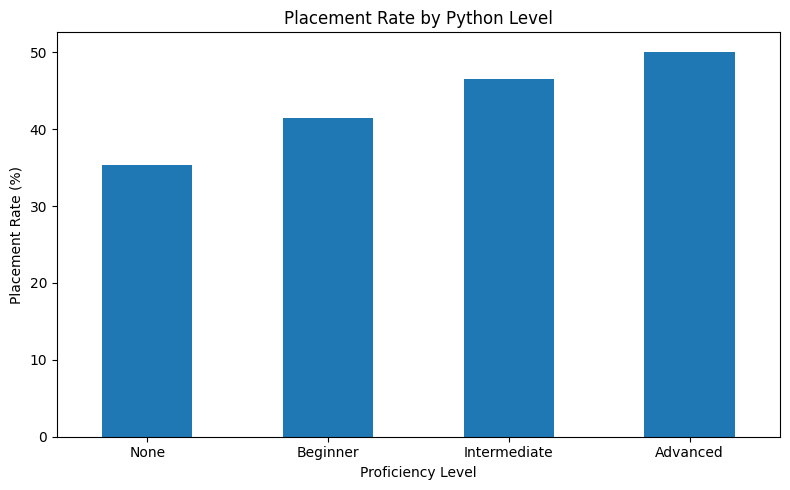

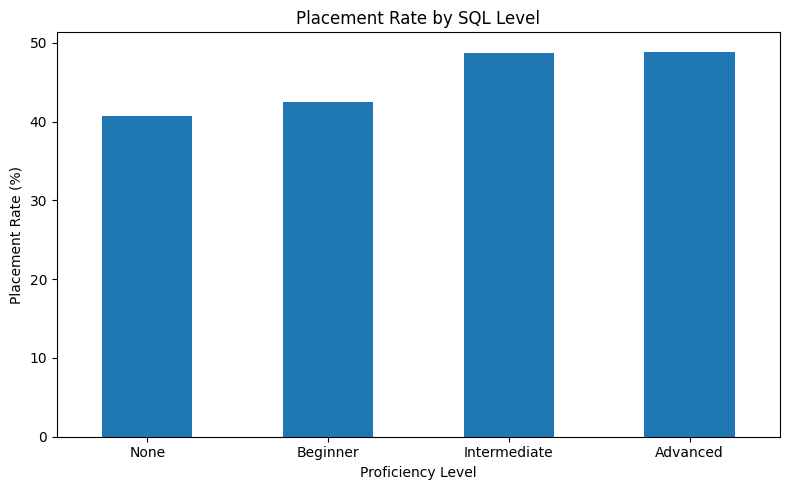

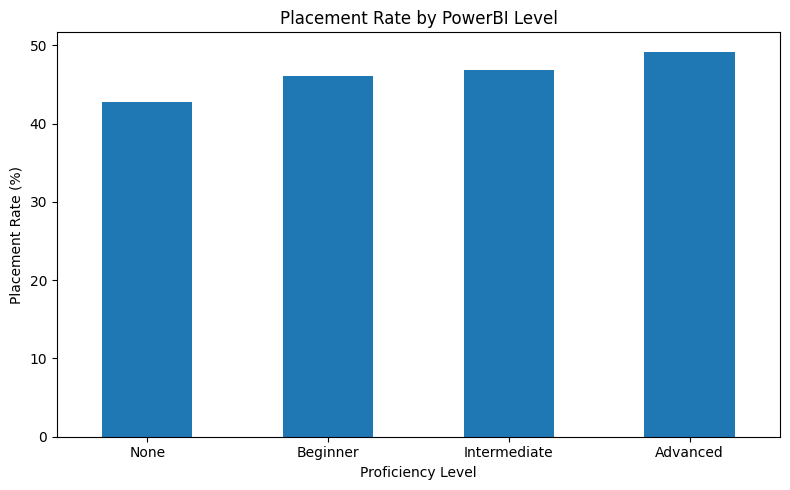

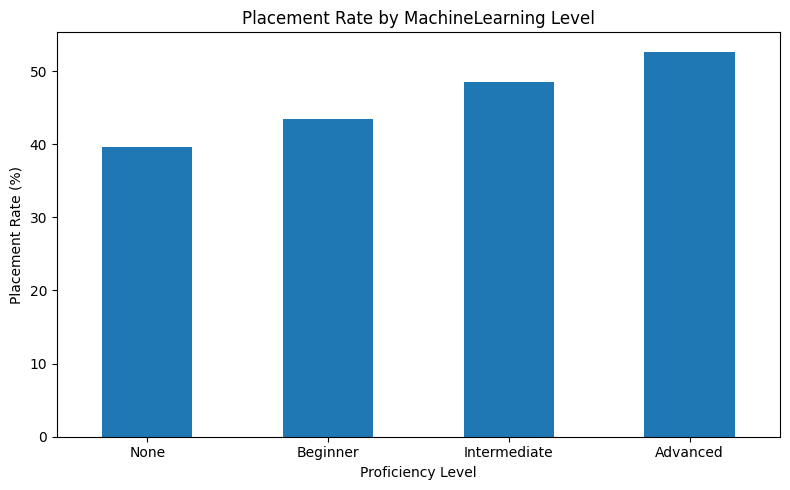

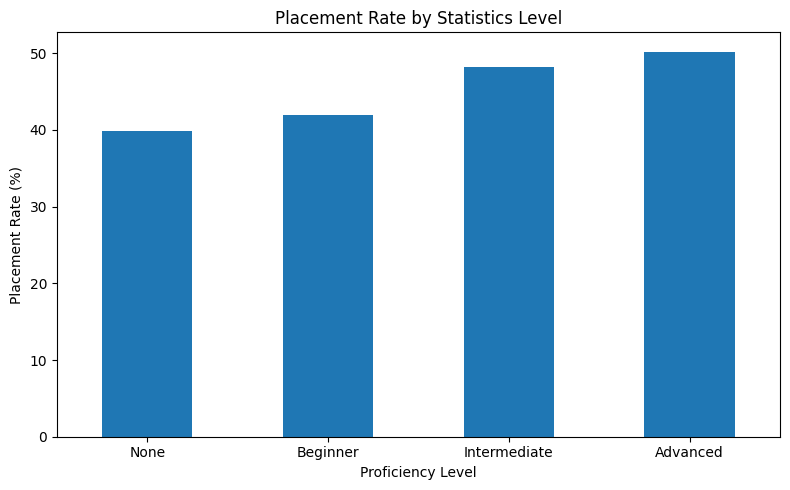

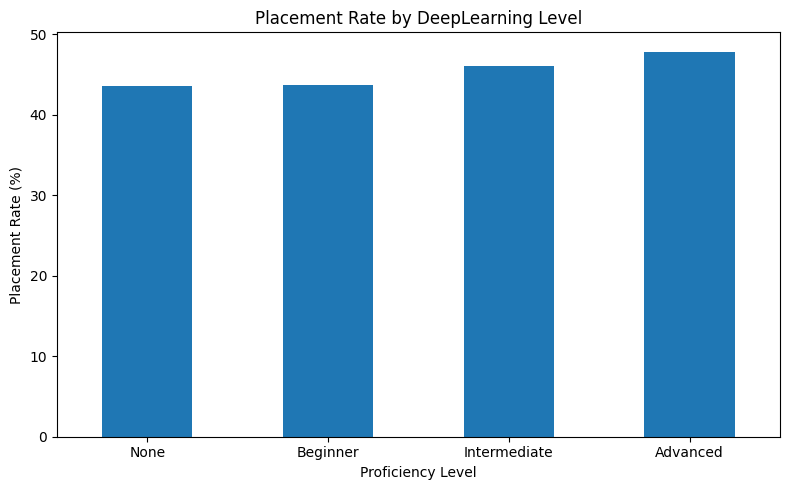

In [180]:
# --------------------------------------------------
# Visualize Placement Rate by Technical Skill Level
# --------------------------------------------------

for skill in technical_skills:

    placement_rate = skill_placement_rates[skill]

    plt.figure(figsize=(8, 5))

    placement_rate.plot(kind="bar")

    plt.title(
        f"Placement Rate by {skill.replace('_', ' ')}"
    )

    plt.xlabel("Proficiency Level")
    plt.ylabel("Placement Rate (%)")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

## 5. Career Profile Analysis

### 5.1 Target Role Distribution

This analysis examines the distribution of students across different target career roles. Understanding career preferences provides a foundation for role-specific skill-gap analysis and personalized career recommendations.

In [181]:
# --------------------------------------------------
# Target Role Distribution
# --------------------------------------------------

target_role_counts = (
    df["Target_Role"]
    .value_counts()
)

target_role_percentages = (
    df["Target_Role"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Target Role Counts:")

print(target_role_counts)


print("\nTarget Role Percentages:")

print(target_role_percentages)

Target Role Counts:
Target_Role
Data Scientist               996
Data Analyst                 990
Machine Learning Engineer    986
AI Engineer                  794
Software Developer           749
Data Engineer                485
Name: count, dtype: int64

Target Role Percentages:
Target_Role
Data Scientist               19.92
Data Analyst                 19.80
Machine Learning Engineer    19.72
AI Engineer                  15.88
Software Developer           14.98
Data Engineer                 9.70
Name: proportion, dtype: float64


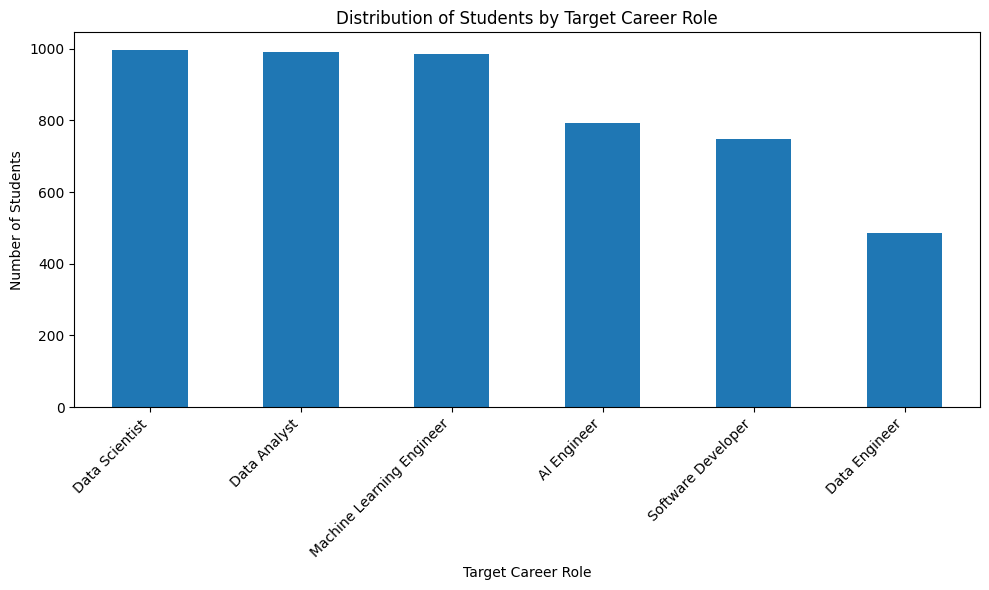

In [182]:
# --------------------------------------------------
# Visualize Target Role Distribution
# --------------------------------------------------

plt.figure(figsize=(10, 6))

target_role_counts.plot(kind="bar")

plt.title("Distribution of Students by Target Career Role")
plt.xlabel("Target Career Role")
plt.ylabel("Number of Students")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

### 5.2 Placement Rate by Target Career Role

This analysis compares placement rates across different target career roles. It helps identify variations in placement outcomes among students pursuing different career paths within the synthetic dataset.

In [183]:
# --------------------------------------------------
# Placement Rate by Target Role
# --------------------------------------------------

role_placement_rate = (
    df.groupby("Target_Role")["Placement_Status"]
    .apply(
        lambda x: (x == "Placed").mean() * 100
    )
    .sort_values(ascending=False)
    .round(2)
)

print("Placement Rate by Target Role:")

print(role_placement_rate)

Placement Rate by Target Role:
Target_Role
Machine Learning Engineer    47.97
AI Engineer                  46.73
Data Scientist               46.29
Data Analyst                 44.34
Software Developer           43.66
Data Engineer                40.82
Name: Placement_Status, dtype: float64


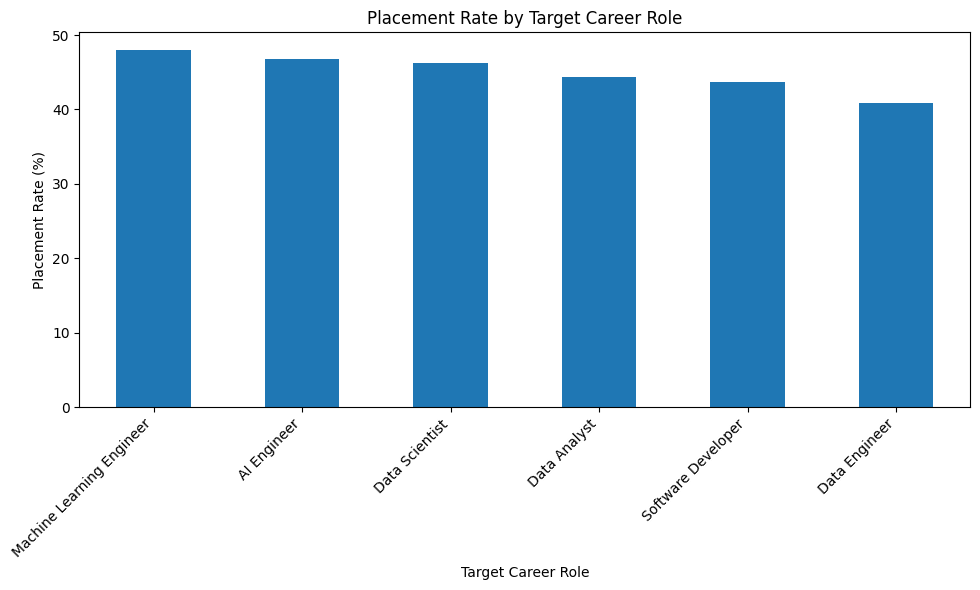

In [184]:
# --------------------------------------------------
# Visualize Placement Rate by Target Role
# --------------------------------------------------

plt.figure(figsize=(10, 6))

role_placement_rate.plot(kind="bar")

plt.title("Placement Rate by Target Career Role")
plt.xlabel("Target Career Role")
plt.ylabel("Placement Rate (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## 6. Multivariate Analysis

### 6.1 Numerical Feature Correlation Analysis

This analysis examines correlations among numerical features to identify relationships, potential multicollinearity, and redundant information before machine learning model development.

`Student_ID` is excluded because it is only an identifier. `Placement_Score` is also excluded because it was used to generate the synthetic target and must not influence feature-selection decisions for the placement prediction model.

In [185]:
# --------------------------------------------------
# Select Numerical Features for Correlation Analysis
# --------------------------------------------------

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


# Exclude non-predictive and leakage-related features
correlation_features = [
    column
    for column in numerical_features
    if column not in [
        "Student_ID",
        "Placement_Score"
    ]
]


print("Numerical Features Used for Correlation Analysis:")

for feature in correlation_features:
    print(feature)

Numerical Features Used for Correlation Analysis:
Age
Graduation_Year
CGPA
LeetCode_Problems
GitHub_Repositories
Total_Projects
AI_ML_Projects
Internship_Count
Industry_Certifications


In [186]:
# --------------------------------------------------
# Calculate Correlation Matrix
# --------------------------------------------------

correlation_matrix = df[
    correlation_features
].corr()

print("Correlation Matrix:")

correlation_matrix.round(2)

Correlation Matrix:


,Age,Graduation_Year,CGPA,LeetCode_Problems,GitHub_Repositories,Total_Projects,AI_ML_Projects,Internship_Count,Industry_Certifications
Age,1.00,-0.03,-0.01,0.00,-0.01,-0.02,0.01,-0.04,0.02
Graduation_Year,-0.03,1.00,-0.01,0.01,0.01,0.00,-0.01,0.02,-0.02
CGPA,-0.01,-0.01,1.00,0.01,0.01,-0.01,-0.01,0.03,0.00
LeetCode_Problems,0.00,0.01,0.01,1.00,0.01,-0.01,-0.00,0.02,0.01
GitHub_Repositories,-0.01,0.01,0.01,0.01,1.00,0.01,-0.00,0.01,0.01
Total_Projects,-0.02,0.00,-0.01,-0.01,0.01,1.00,0.57,-0.00,0.01
AI_ML_Projects,0.01,-0.01,-0.01,-0.00,-0.00,0.57,1.00,-0.01,0.01
Internship_Count,-0.04,0.02,0.03,0.02,0.01,-0.00,-0.01,1.00,-0.00
Industry_Certifications,0.02,-0.02,0.00,0.01,0.01,0.01,0.01,-0.00,1.00


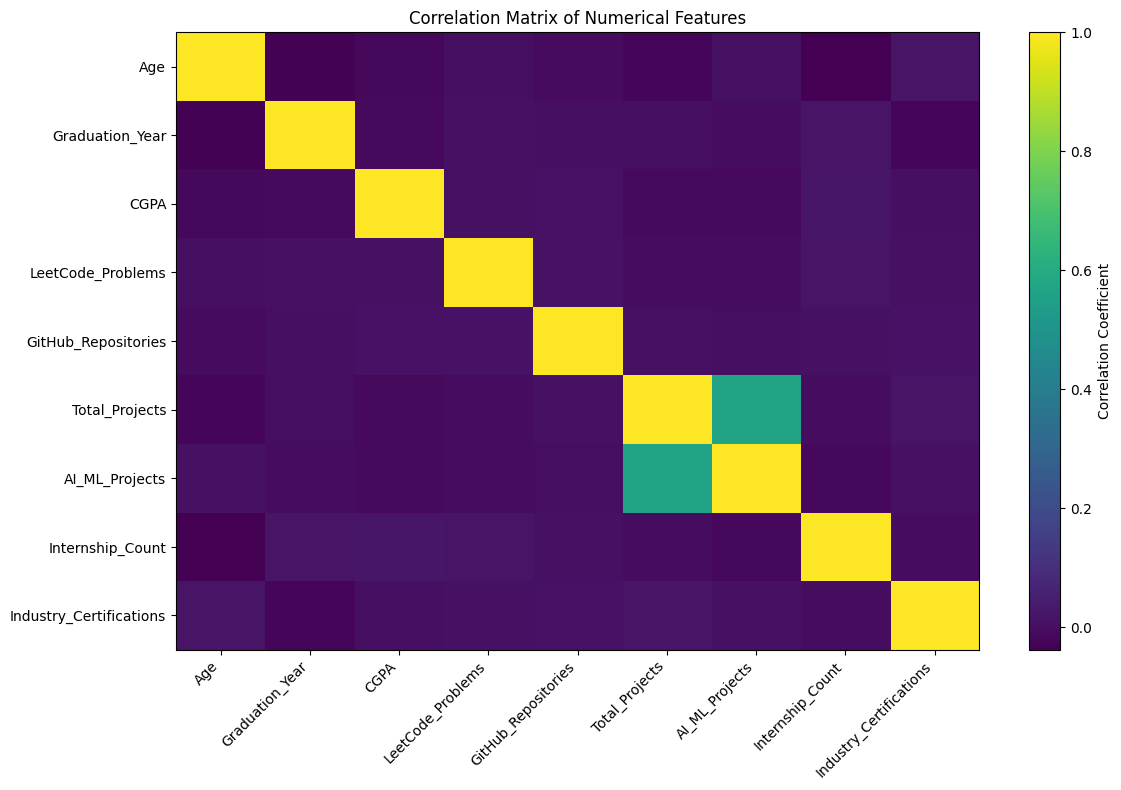

In [187]:
# --------------------------------------------------
# Visualize Correlation Matrix
# --------------------------------------------------

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation Coefficient"
)

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

### 6.2 Identification of Highly Correlated Numerical Features

This analysis identifies numerical feature pairs with relatively strong correlations. Detecting highly related features can help identify redundant information and support feature-selection decisions before machine learning model development.

In [188]:
# --------------------------------------------------
# Identify Strongly Correlated Feature Pairs
# --------------------------------------------------

strong_correlations = []


for i in range(len(correlation_features)):

    for j in range(i + 1, len(correlation_features)):

        feature_1 = correlation_features[i]

        feature_2 = correlation_features[j]

        correlation_value = correlation_matrix.loc[
            feature_1,
            feature_2
        ]


        if abs(correlation_value) >= 0.50:

            strong_correlations.append(
                {
                    "Feature_1": feature_1,
                    "Feature_2": feature_2,
                    "Correlation": round(
                        correlation_value,
                        3
                    )
                }
            )


# Convert results into DataFrame

strong_correlations_df = pd.DataFrame(
    strong_correlations
)


# Display results

if strong_correlations_df.empty:

    print(
        "No numerical feature pairs with "
        "|correlation| >= 0.50 were found."
    )

else:

    strong_correlations_df = (
        strong_correlations_df
        .sort_values(
            by="Correlation",
            key=abs,
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(
        "Numerical Feature Pairs with "
        "|Correlation| >= 0.50:"
    )

    strong_correlations_df

Numerical Feature Pairs with |Correlation| >= 0.50:


### 6.3 Profile-Building Features vs Placement Status

This analysis examines placement rates based on students' professional profile-building activities, including LinkedIn presence, GitHub presence, and portfolio website availability.

In [189]:
# --------------------------------------------------
# Profile-Building Features vs Placement Status
# --------------------------------------------------

profile_features = [
    "LinkedIn_Profile",
    "GitHub_Profile",
    "Portfolio_Website"
]

profile_placement_rates = {}

for feature in profile_features:

    placement_rate = (
        df.groupby(feature)["Placement_Status"]
        .apply(lambda x: (x == "Placed").mean() * 100)
        .round(2)
    )

    profile_placement_rates[feature] = placement_rate

    print("\n" + "=" * 50)
    print(f"Placement Rate by {feature}:")
    print(placement_rate)


Placement Rate by LinkedIn_Profile:
LinkedIn_Profile
No     42.66
Yes    46.03
Name: Placement_Status, dtype: float64

Placement Rate by GitHub_Profile:
GitHub_Profile
No     31.25
Yes    45.43
Name: Placement_Status, dtype: float64

Placement Rate by Portfolio_Website:
Portfolio_Website
No     43.00
Yes    50.18
Name: Placement_Status, dtype: float64


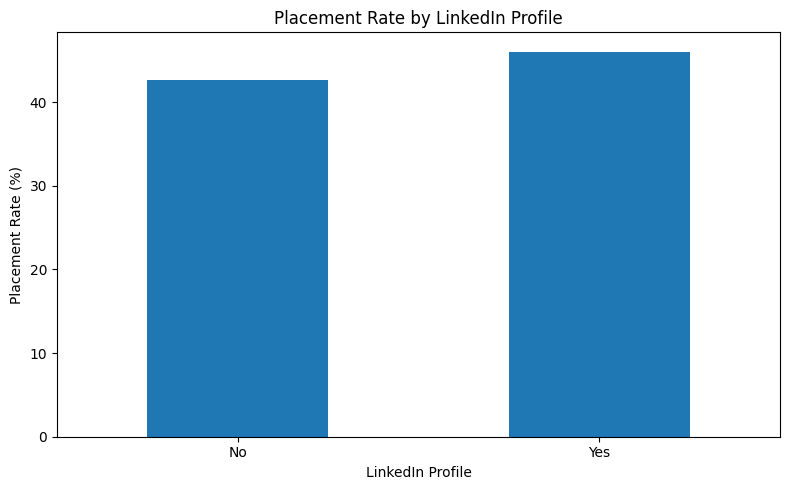

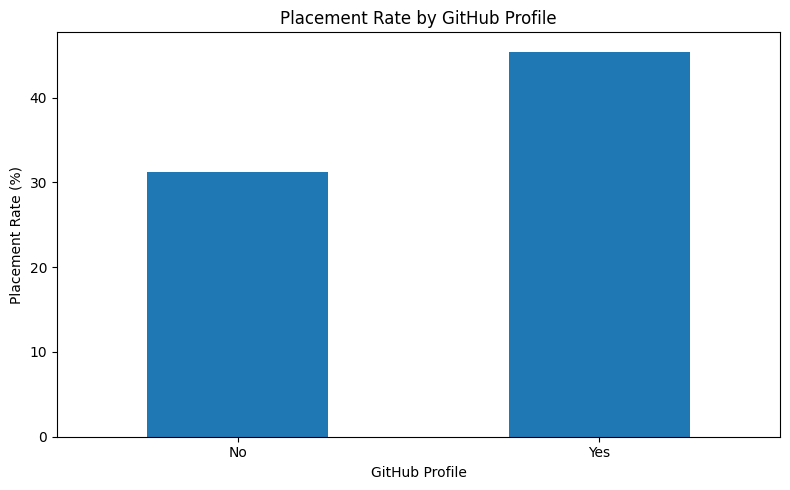

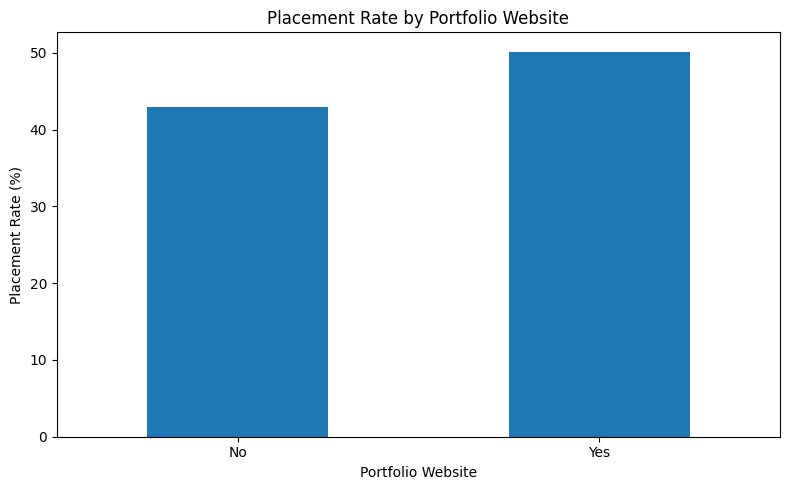

In [190]:
# --------------------------------------------------
# Visualize Profile Features vs Placement Status
# --------------------------------------------------

for feature in profile_features:

    placement_rate = profile_placement_rates[feature]

    plt.figure(figsize=(8, 5))

    placement_rate.plot(kind="bar")

    plt.title(
        f"Placement Rate by {feature.replace('_', ' ')}"
    )

    plt.xlabel(feature.replace("_", " "))
    plt.ylabel("Placement Rate (%)")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

### 6.4 Industry Certifications vs Placement Status

This analysis examines placement rates across different numbers of industry certifications. It helps evaluate whether additional professional certifications are associated with placement outcomes within the synthetic dataset.

In [191]:
# --------------------------------------------------
# Certification Statistics by Placement Status
# --------------------------------------------------

certification_statistics = (
    df.groupby("Placement_Status")["Industry_Certifications"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("Certification Statistics by Placement Status:")

certification_statistics

Certification Statistics by Placement Status:


,count,mean,median,std
Placement_Status,,,,
Not Placed,2731,2.54,2.0,2.05
Placed,2269,2.81,2.0,2.14


In [192]:
# --------------------------------------------------
# Placement Rate by Number of Certifications
# --------------------------------------------------

certification_placement_rate = (
    df.groupby("Industry_Certifications")["Placement_Status"]
    .apply(
        lambda x: (x == "Placed").mean() * 100
    )
    .sort_index()
    .round(2)
)

print("Placement Rate by Number of Certifications:")

print(certification_placement_rate)

Placement Rate by Number of Certifications:
Industry_Certifications
0    40.82
1    43.66
2    44.05
3    45.32
4    46.99
5    52.15
6    46.87
7    53.37
8    55.24
Name: Placement_Status, dtype: float64


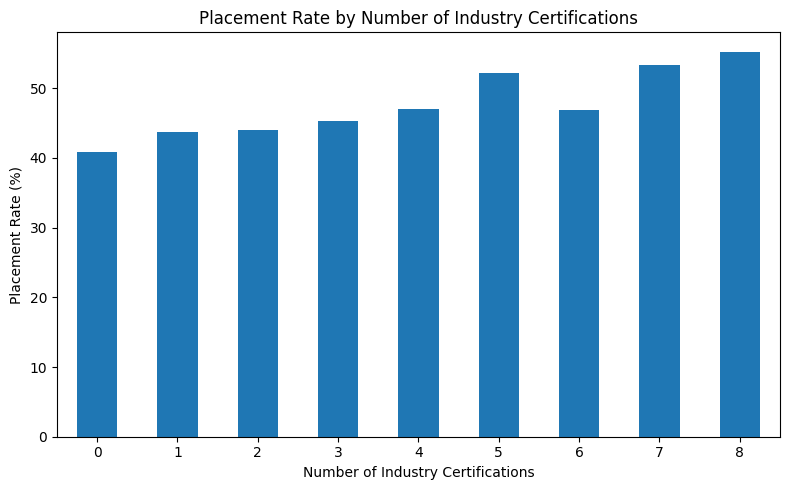

In [193]:
# --------------------------------------------------
# Visualize Placement Rate by Certifications
# --------------------------------------------------

plt.figure(figsize=(8, 5))

certification_placement_rate.plot(kind="bar")

plt.title("Placement Rate by Number of Industry Certifications")
plt.xlabel("Number of Industry Certifications")
plt.ylabel("Placement Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 6.5 Preferred Domain vs Placement Status

This analysis examines placement rates across students' preferred technical domains. It helps explore whether placement outcomes vary among different areas of specialization within the synthetic dataset.

In [194]:
# --------------------------------------------------
# Preferred Domain Distribution
# --------------------------------------------------

domain_counts = (
    df["Preferred_Domain"]
    .value_counts()
)

domain_percentages = (
    df["Preferred_Domain"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Preferred Domain Counts:")
print(domain_counts)

print("\nPreferred Domain Percentages:")
print(domain_percentages)

Preferred Domain Counts:
Preferred_Domain
AI/ML                   1780
Data Science             996
Data Analytics           990
Software Development     749
Data Engineering         485
Name: count, dtype: int64

Preferred Domain Percentages:
Preferred_Domain
AI/ML                   35.60
Data Science            19.92
Data Analytics          19.80
Software Development    14.98
Data Engineering         9.70
Name: proportion, dtype: float64


In [195]:
# --------------------------------------------------
# Placement Rate by Preferred Domain
# --------------------------------------------------

domain_placement_rate = (
    df.groupby("Preferred_Domain")["Placement_Status"]
    .apply(
        lambda x: (x == "Placed").mean() * 100
    )
    .sort_values(ascending=False)
    .round(2)
)

print("Placement Rate by Preferred Domain:")

print(domain_placement_rate)

Placement Rate by Preferred Domain:
Preferred_Domain
AI/ML                   47.42
Data Science            46.29
Data Analytics          44.34
Software Development    43.66
Data Engineering        40.82
Name: Placement_Status, dtype: float64


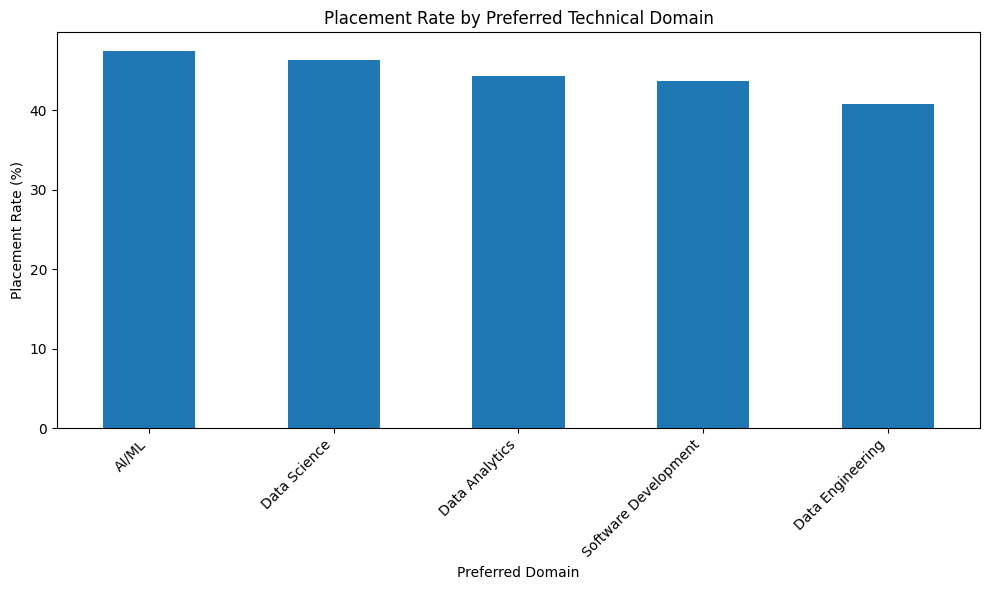

In [196]:
# --------------------------------------------------
# Visualize Placement Rate by Preferred Domain
# --------------------------------------------------

plt.figure(figsize=(10, 6))

domain_placement_rate.plot(kind="bar")

plt.title("Placement Rate by Preferred Technical Domain")
plt.xlabel("Preferred Domain")
plt.ylabel("Placement Rate (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## 7. EDA Summary and Key Findings

The exploratory data analysis provided insights into the structure, distributions, and relationships present within the Career Compass student placement dataset.

### Key Findings

- The dataset contains 5,000 student records and 31 features after data cleaning.
- The target variable, `Placement_Status`, is reasonably balanced between placed and non-placed students.
- Academic performance, coding practice, project experience, internships, communication proficiency, and technical skill levels show varying associations with placement outcomes.
- Students with different DSA proficiency levels demonstrate differences in placement rates within the synthetic dataset.
- Technical skills such as Python, SQL, Power BI, Machine Learning, Statistics, and Deep Learning were analyzed individually to understand their relationships with placement outcomes.
- Professional profile-building features, including LinkedIn, GitHub, and portfolio website presence, were examined for their association with placement outcomes.
- Industry certifications and practical experience features provide additional information about student career readiness.
- Target roles and preferred domains provide an important foundation for the future role-specific skill-gap analysis and personalized recommendation system.
- Numerical correlation analysis did not identify feature pairs with an absolute correlation of 0.50 or higher among the analyzed numerical features.
- `DSA_Level` and `LeetCode_Problems` have a known dependency by dataset design and will be carefully evaluated during model preprocessing and feature selection.
- `Placement_Score` was excluded from model-oriented correlation analysis because it was used during synthetic target generation.

### Important Modeling Decision

`Placement_Score` will **not** be used as an input feature when training the machine learning model to predict `Placement_Status`.

Including this feature would introduce **target leakage** because `Placement_Score` was used as part of the synthetic target-generation process. Using it as a predictor could produce misleadingly high model performance and poor evaluation validity.

Therefore:

- `Placement_Status` will be used as the target variable.
- `Placement_Score` may be retained only for exploratory analysis if needed.
- `Placement_Score` will be explicitly removed from the machine learning input features before model training.

### Next Phase

The next phase of the Career Compass project will focus on:

- Machine learning preprocessing
- Feature selection
- Train-test splitting
- Categorical feature encoding
- Numerical feature scaling where appropriate
- Model training and comparison
- Model evaluation
- Feature importance analysis
- Selection and saving of the final prediction model

The insights obtained during EDA will guide these machine learning development decisions.